# 04. Segunda prueba

Usamos las recuperaciones del experimento 03. En esta prueba cambiamos cómo se presentan los pasajes, cómo responde el modelo y cómo se revisan las citas.

Primero revisamos cobertura y salidas anteriores. Después generamos respuestas nuevas y comparamos las tres variantes sobre las mismas 50 preguntas.


## Preparación

En Colab, seleccionar GPU A100. Subir `data/colab/ai-week-v04.zip` a `Mi unidad/AIWEEK`, sin descomprimir. Abrir este notebook desde Drive.

En local, abrirlo desde el proyecto. Los resultados nuevos quedan en `experimentos/v04/`.


In [1]:
from pathlib import Path
import hashlib, importlib.metadata, json, os, platform, subprocess, sys, zipfile

MODO = "auto"
CARPETA_DRIVE = "/content/drive/MyDrive/AIWEEK"
PAQUETE = "ai-week-v04.zip"

os.environ.update(USE_TF="0", USE_TORCH="1", USE_FLAX="0", TRANSFORMERS_NO_TF="1",
                  CUBLAS_WORKSPACE_CONFIG=":4096:8")
try:
    import google.colab
    detectado_colab = True
except ImportError:
    detectado_colab = False
EN_COLAB = detectado_colab if MODO == "auto" else MODO == "colab"

def hash_archivo(ruta):
    h = hashlib.sha256()
    with Path(ruta).open("rb") as archivo:
        for bloque in iter(lambda: archivo.read(8 * 1024 * 1024), b""):
            h.update(bloque)
    return h.hexdigest()

if EN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE = Path(CARPETA_DRIVE)
    paquete = DRIVE / PAQUETE
    if not paquete.is_file():
        raise FileNotFoundError(f"Subir {PAQUETE} a {DRIVE}")
    RAIZ = Path("/content/aiweek") / ("v04-" + hash_archivo(paquete)[:12])
    if not (RAIZ / ".paquete_verificado").is_file():
        RAIZ.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(paquete) as z:
            for nombre in z.namelist():
                if not (RAIZ / nombre).resolve().is_relative_to(RAIZ.resolve()):
                    raise ValueError("Ruta inválida dentro del ZIP")
            z.extractall(RAIZ)
        inventario = json.loads((RAIZ / "paquete.json").read_text(encoding="utf-8"))
        for nombre, esperado in inventario["sha256_archivos"].items():
            if hash_archivo(RAIZ / nombre) != esperado:
                raise ValueError(f"Archivo incompleto: {nombre}")
        (RAIZ / ".paquete_verificado").write_text("ok")
    if not (RAIZ / "src/legalrag/generation/politica.py").is_file():
        raise FileNotFoundError("El ZIP no contiene la generación del 04. Regenerarlo")
    dependencias = RAIZ / "requirements/colab.txt"
    firma = hash_archivo(dependencias) + platform.python_version()
    marca = Path("/content/aiweek_experimentos_dependencias.txt")
    if not marca.exists() or marca.read_text() != firma:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(dependencias)], check=True)
        marca.write_text(firma)
    RESULTADOS = DRIVE / "experimentos"
    CACHE_MODELOS = DRIVE / "modelos_cache"
    os.environ["HF_HOME"] = str(RAIZ / "data/cache_huggingface")
else:
    RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs/experimentos.json").is_file()), None)
    if RAIZ is None:
        raise FileNotFoundError("Abrir el notebook desde el proyecto")
    RESULTADOS = RAIZ / "data/experimentos_sistema"
    CACHE_MODELOS = None

os.chdir(RAIZ)
if str(RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RAIZ / "src"))
print("Entorno:", "Colab" if EN_COLAB else "local", "| Resultados:", RESULTADOS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Colab | Resultados: /content/drive/MyDrive/AIWEEK/experimentos


## Ejecución anterior

Se usa la última ejecución del 03 y su recuperación. Si hace falta otra, escribir los nombres de las carpetas en la siguiente celda.


In [2]:
import pandas as pd
from IPython.display import display
from legalrag.experimentos import v04

ejecucion_03 = ""
recuperacion_03 = ""
variantes = ["densa", "hibrida", "densa_reranker"]

puntero = json.loads((RESULTADOS / "ultima_ejecucion.json").read_text(encoding="utf-8"))
CARPETA_03 = RESULTADOS / "ejecuciones" / (ejecucion_03 or Path(puntero["carpeta"]).name)
config_03 = json.loads((CARPETA_03 / "configuracion.json").read_text(encoding="utf-8"))
CARPETA_RECUP = RESULTADOS / "recuperaciones" / (recuperacion_03 or Path(config_03["recuperacion"]).name)
print("03:", CARPETA_03.name, "| recuperación:", CARPETA_RECUP.name)
resumen_03 = pd.read_csv(CARPETA_03 / "resumen.csv").set_index("variante")
display(resumen_03[["total_50", "cerradas_20", "citas_20", "abstencion_10", "abstenciones", "errores_esquema"]])

03: 20260927T234832400022Z | recuperación: 20260927T232943218185Z


,total_50,cerradas_20,citas_20,abstencion_10,abstenciones,errores_esquema
variante,,,,,,
densa,11.04,4.00,2.04,5.00,38,11
hibrida,10.68,5.33,0.82,4.53,32,6
densa_reranker,14.35,6.67,2.45,5.23,35,7


## Cobertura del corpus

Revisamos si las normas de referencia están en el corpus y si llegaron a los pasajes del 03. Una norma ausente no se arregla cambiando el prompt.

La tabla del banco muestra prioridades para ampliar el corpus. No cambia los archivos ni el índice.


In [3]:
from legalrag.ingestion.cobertura import auditar, auditar_banco, indice_corpus

preguntas, entradas = v04.muestra(RAIZ)
indice = indice_corpus(RAIZ)
recups = {}
ev = v04.evidencia(RAIZ)
for variante in variantes:
    recups[variante] = {i: ev.reconstruir(p)[0] for i, p in v04.recuperacion_03(CARPETA_RECUP, variante).items()}
cobertura = pd.DataFrame(auditar(RAIZ, preguntas, recuperaciones=recups, indice=indice))
con_cita = cobertura[cobertura["estado_corpus"] != "sin_cita_extraible"]
print("Citas de referencia en la muestra:", len(con_cita))
display(pd.concat({v: con_cita[v].value_counts() for v in variantes}, axis=1).fillna(0).astype(int))
display(con_cita.groupby("area")["estado_corpus"].value_counts().unstack(fill_value=0))

banco = pd.DataFrame(auditar_banco(RAIZ, indice=indice))
total = banco["items_del_banco"].sum()
print(f"Banco de 992: {banco.loc[banco.en_corpus, 'items_del_banco'].sum()}/{total} menciones de norma cubiertas")
display(banco[~banco.en_corpus].sort_values("items_del_banco", ascending=False).head(15)[["norma", "items_del_banco", "areas", "donde_buscar"]])

Citas de referencia en la muestra: 61


,densa,hibrida,densa_reranker
recuperada,31,28,33
norma_ausente,22,22,22
no_recuperada,8,11,6


estado_corpus,articulo_ausente,norma_ausente,presente
area,,,
Derecho administrativo,0,1,5
Derecho civil,0,2,0
Derecho comercial y sociedades,0,3,2
Derecho constitucional,0,3,6
Derecho de familia,0,5,0
"Derecho de los mercados [competencia, consumidor, datos personales y propiedad intelectual]",0,0,7
Derecho laboral,3,7,3
Derecho penal,0,0,4
Derecho procesal,0,0,7


Banco de 992: 351/559 menciones de norma cubiertas


,norma,items_del_banco,areas,donde_buscar
2,Codigo sustantivo trabajo,37,[Derecho laboral],http://www.secretariasenado.gov.co/senado/base...
13,Sentencia C-207 de 2019,4,[Derecho administrativo],https://www.corteconstitucional.gov.co/relator...
14,Sentencia SL-3385 de 2022,4,[Derecho laboral],https://www.corteconstitucional.gov.co/relator...
15,Sentencia T-323 de 2024,4,[Derecho constitucional],https://www.corteconstitucional.gov.co/relator...
17,Sentencia C-394 de 2017,3,"[Derecho constitucional, Derecho de familia]",https://www.corteconstitucional.gov.co/relator...
19,Sentencia SU-315 de 2025,3,[Derecho civil],https://www.corteconstitucional.gov.co/relator...
20,Sentencia T-243 de 2018,3,[Derecho laboral],https://www.corteconstitucional.gov.co/relator...
28,Ley 979 de 2005,3,[Derecho de familia],https://www.suin-juriscol.gov.co/legislacion/?...
29,Decreto 1563 de 2012,2,[Derecho procesal],https://www.suin-juriscol.gov.co/legislacion/?...
30,Sentencia C-117 de 2018,2,[Derecho tributario],https://www.corteconstitucional.gov.co/relator...


## Revisar las salidas del 03

Aplicamos las reglas nuevas al texto ya generado, sin usar GPU. Esto permite medir qué aporta la revisión de formato y citas antes de volver a generar.


In [4]:
SALIDA_REPUNTUADA = RESULTADOS / "v04" / ("repuntuado_" + CARPETA_03.name)
repuntuado = v04.repuntuar_03(RAIZ, CARPETA_03, CARPETA_RECUP, variantes, SALIDA_REPUNTUADA)
tabla_rep = pd.DataFrame(repuntuado).T
tabla_rep.insert(0, "total_03", resumen_03.loc[tabla_rep.index, "total_50"])
display(tabla_rep[["total_03", "total_50", "cerradas_20", "citas_20", "abstencion_10", "abstenciones", "tasa_sin_respaldo", "errores_esquema"]])
for variante in variantes:
    notas = pd.read_json(SALIDA_REPUNTUADA / variante / "notas.json")
    print(variante, notas["motivo"].value_counts().to_dict())

,total_03,total_50,cerradas_20,citas_20,abstencion_10,abstenciones,tasa_sin_respaldo,errores_esquema
densa,11.04,25.82,10.67,9.80,5.35,0.0,0.0,0.0
hibrida,10.68,23.60,9.33,9.39,4.88,0.0,0.0,0.0
densa_reranker,14.35,28.42,12.00,10.61,5.81,0.0,0.0,0.0


densa {'ok': 42, 'reparado': 8}
hibrida {'ok': 44, 'reparado': 6}
densa_reranker {'ok': 41, 'reparado': 9}


## Generar otra vez

Primero corremos seis preguntas con fallos conocidos. Si sus respuestas salen bien, ejecutamos las 50 preguntas en cada variante. Cada respuesta se guarda al terminar.

La celda muestra la GPU real. En Colab se detiene si no es una A100.


In [5]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("Seleccionar GPU A100 en Colab o una GPU NVIDIA en local")

gpu_actual = torch.cuda.get_device_name(0)
memoria_gpu = torch.cuda.get_device_properties(0).total_memory / 2**30
print(f"GPU: {gpu_actual} | memoria: {memoria_gpu:.0f} GiB")
if EN_COLAB and "A100" not in gpu_actual.upper():
    raise RuntimeError("Colab no asignó una A100. Cambiar el tipo de GPU antes de generar")

etiqueta_gpu = "a100" if "A100" in gpu_actual.upper() else "local"
config = {
    "decoder": "salamandra-7b-instruct",
    "max_tokens": 900,
    "repeat_penalty": 1.1,
    "politica": {"citar_evidencia": "todas", "abstener_libre": "sin_evidencia"},
}
prueba_ids = [51, 308, 24, 168, 472, 919]
carpeta_prueba = v04.ejecutar(RAIZ, CARPETA_RECUP, RESULTADOS, ["densa"], config=config,
                              cache_modelos=CACHE_MODELOS, nombre=f"prueba_salamandra_{etiqueta_gpu}",
                              solo_ids=prueba_ids)
for i in prueba_ids:
    fila = json.loads((carpeta_prueba / "densa" / "respuestas" / f"{i}.json").read_text(encoding="utf-8"))
    respuesta, registro = fila["respuesta"], fila["registro"]
    print(f"\n{i} | {respuesta['formato']} | fin: {registro.get('finish_reason')} | "
          f"tokens: {registro.get('tokens_salida')} | reparado: {registro.get('reparado')}")
    display({k: v for k, v in respuesta.items() if k != "pasajes_recuperados"})
    if fila["postproceso"]["oraciones_eliminadas"]:
        print("Oraciones eliminadas por citas sin respaldo:", fila["postproceso"]["oraciones_eliminadas"])


GPU: NVIDIA A100-SXM4-40GB | memoria: 39 GiB
Restaurando Salamandra desde la copia guardada
densa: 1/6
densa: 2/6
densa: 3/6
densa: 4/6
densa: 5/6
densa: 6/6

51 | multiple_choice | fin: eos | tokens: 218 | reparado: False


{'id': 51,
 'formato': 'multiple_choice',
 'respuesta_correcta': 'C',
 'justificacion': 'La acción judicial de grupo está prevista en la Ley 472 de 1998, artículo 3, para obtener el reconocimiento y pago de indemnización de los perjuicios causados a un grupo de personas que reúnen condiciones uniformes respecto de una misma causa. Fundamento: Ley 472 de 1998, artículos 2, 3, 46 y 21; Código de Procedimiento Administrativo y de lo Contencioso Administrativo, artículo 144.',
 'descarte_opciones': {'A': 'No procede porque la acción judicial de grupo no busca proteger derechos fundamentales individuales de aplicación inmediata.',
  'B': 'No procede porque la acción judicial de grupo no se ejerce para defender intereses colectivos ambientales o del espacio público.',
  'D': 'No procede porque la acción judicial de grupo no tiene por objetivo declarar la inconstitucionalidad de una norma con fuerza de ley.'},
 'abstencion': False,
 'latencia_ms': 3096}


308 | multiple_choice | fin: eos | tokens: 149 | reparado: False


{'id': 308,
 'formato': 'multiple_choice',
 'respuesta_correcta': 'A',
 'justificacion': 'El texto dice que si vencido el plazo anteriormente establecido no se ha realizado la liquidación, la misma podrá ser realizada en cualquier tiempo dentro de los dos años siguientes al vencimiento del término a que se refieren los incisos anteriores, de mutuo acuerdo o unilateralmente, sin perjuicio de lo previsto en el artículo 136 del C. C. A. Fundamento: Ley 1150 de 2007, artículo 11; Código de Procedimiento Administrativo y de lo Contencioso Administrativo, artículo 164; Ley 446 de 1998, artículo 44; Código de Comercio, artículos 1249 y 1419.',
 'descarte_opciones': {'B': 'No hay plazo', 'C': 'Dos años', 'D': '4 meses'},
 'abstencion': False,
 'latencia_ms': 2404}


24 | semi_open | fin: eos | tokens: 103 | reparado: False


...


472 | semi_open | fin: eos | tokens: 183 | reparado: False


{'id': 472,
 'formato': 'semi_open',
 'respuesta': 'Los requisitos que exige la ley para el control de integraciones empresariales son: 1) Cuando, en conjunto o individualmente consideradas, hayan tenido durante el año fiscal anterior a la operación proyectada ingresos operacionales superiores al monto que, en salarios mínimos legales mensuales vigentes, haya establecido la Superintendencia de Industria y Comercio, o 2) Cuando al finalizar el año fiscal anterior a la operación proyectada tuviesen, en conjunto o individualmente consideradas, activos totales superiores al monto que, en salarios mínimos legales mensuales vigentes, haya establecido la Superintendencia de Industria y Comercio.',
 'palabras_clave': ['integraciones', 'empresariales', 'ley', 'requisitos'],
 'referencia_legal': 'Ley 1340 de 2009, artículos 9, 11 y 10; Ley 489 de 1998, artículo 106; Decreto 1074 de 2015, artículo 2',
 'abstencion': False,
 'latencia_ms': 2578}


919 | semi_open | fin: eos | tokens: 137 | reparado: False


{'id': 919,
 'formato': 'semi_open',
 'respuesta': 'Según los pasajes recuperados, la respuesta depende de las normas citadas.',
 'palabras_clave': ['unificación',
  'jurisprudencia',
  'procedibilidad',
  'tutela',
  'derecho al trabajo',
  'igualdad'],
 'referencia_legal': 'Sentencia C-55 de 2022; Sentencia C-489 de 2023',
 'abstencion': False,
 'latencia_ms': 2387}

Oraciones eliminadas por citas sin respaldo: ['El problema jurídico abordado en la sentencia SU-455 de 2020 de la Corte Constitucional es sobre la unificación de la jurisprudencia constitucional relacionada con la procedencia de la acción de tutela para proteger el derecho al trabajo y el derecho a la igualdad en casos de despidos injustificados.', 'Sentencia SU-455 de 2020 de la Corte Constitucional']


In [6]:
nombre_04 = f"salamandra_v04_{etiqueta_gpu}"
CARPETA_04 = v04.ejecutar(RAIZ, CARPETA_RECUP, RESULTADOS, variantes, config=config,
                          cache_modelos=CACHE_MODELOS, nombre=nombre_04)
print("Guardado en", CARPETA_04)

densa: 1/50
densa: 2/50
densa: 3/50
densa: 4/50
densa: 5/50
densa: 6/50
densa: 7/50
densa: 8/50
densa: 9/50
densa: 10/50
densa: 11/50
densa: 12/50
densa: 13/50
densa: 14/50
densa: 15/50
densa: 16/50
densa: 17/50
densa: 18/50
densa: 19/50
densa: 20/50
densa: 21/50
densa: 22/50
densa: 23/50
densa: 24/50
densa: 25/50
densa: 26/50
densa: 27/50
densa: 28/50
densa: 29/50
densa: 30/50
densa: 31/50
densa: 32/50
densa: 33/50
densa: 34/50
densa: 35/50
densa: 36/50
densa: 37/50
densa: 38/50
densa: 39/50
densa: 40/50
densa: 41/50
densa: 42/50
densa: 43/50
densa: 44/50
densa: 45/50
densa: 46/50
densa: 47/50
densa: 48/50
densa: 49/50
densa: 50/50
hibrida: 1/50
hibrida: 2/50
hibrida: 3/50
hibrida: 4/50
hibrida: 5/50
hibrida: 6/50
hibrida: 7/50
hibrida: 8/50
hibrida: 9/50
hibrida: 10/50
hibrida: 11/50
hibrida: 12/50
hibrida: 13/50
hibrida: 14/50
hibrida: 15/50
hibrida: 16/50
hibrida: 17/50
hibrida: 18/50
hibrida: 19/50
hibrida: 20/50
hibrida: 21/50
hibrida: 22/50
hibrida: 23/50
hibrida: 24/50
hibrida:

## Comparar con el 03

La tabla muestra puntos, citas, abstenciones y preguntas que mejoraron o empeoraron. Con 50 preguntas, revisar los casos concretos antes de elegir una variante.


In [7]:
resumen_04 = pd.DataFrame({v: json.loads((CARPETA_04 / v / "resumen.json").read_text()) for v in variantes}).T
resumen_04.insert(0, "total_03", resumen_03.loc[resumen_04.index, "total_50"])
display(resumen_04[["total_03", "total_50", "cerradas_20", "aciertos_cerradas", "citas_20", "recall_citas",
                    "tasa_sin_respaldo", "abstencion_10", "abstenciones", "errores_esquema"]])

pareadas = {v: v04.comparar(RAIZ, CARPETA_03, CARPETA_04, v) for v in variantes}
display(pd.concat({v: t["cambio"].value_counts() for v, t in pareadas.items()}, axis=1).fillna(0).astype(int))

,total_03,total_50,cerradas_20,aciertos_cerradas,citas_20,recall_citas,tasa_sin_respaldo,abstencion_10,abstenciones,errores_esquema
densa,11.04,29.99,13.33,10.0,10.61,0.5306,0.0,6.05,0.0,0.0
hibrida,10.68,27.38,12.00,9.0,9.80,0.4898,0.0,5.58,0.0,0.0
densa_reranker,14.35,24.88,9.33,7.0,10.20,0.5102,0.0,5.35,0.0,0.0


,densa,hibrida,densa_reranker
cambio,,,
igual_mal,23,25,25
arreglada,21,19,17
igual_bien,5,5,6
rota,1,1,2


## Fallos por área

La gráfica muestra tres señales distintas: cerradas incorrectas, citas de referencia no encontradas en la respuesta y abstenciones. Cada barra indica fallos sobre preguntas evaluables de esa área.

La muestra tiene pocas preguntas por área. El juez oficial no da corrección de texto libre por pregunta, así que esta gráfica no mide toda la calidad jurídica.


Variante: densa


/tmp/ipykernel_5972/1668741353.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  detalle_area["cerrada_fallida"] = detalle_area["cerrada"] & ~detalle_area["acierto_cerrada"].fillna(False).astype(bool)


,preguntas,cerradas,cerradas_fallidas,con_cita,sin_cita_correcta,abstenciones
area,,,,,,
Derecho tributario,4,1,1,2,2,0
Derecho administrativo,7,3,0,5,3,0
Derecho civil,4,1,0,2,1,0
Derecho comercial y sociedades,5,1,1,4,2,0
Derecho constitucional,6,2,0,5,2,0
Derecho laboral,5,1,1,5,2,0
Derecho procesal,5,2,1,5,2,0
Derecho de familia,5,2,1,5,1,0
"Derecho de los mercados [competencia, consumidor, datos personales y propiedad intelectual]",5,1,0,4,0,0


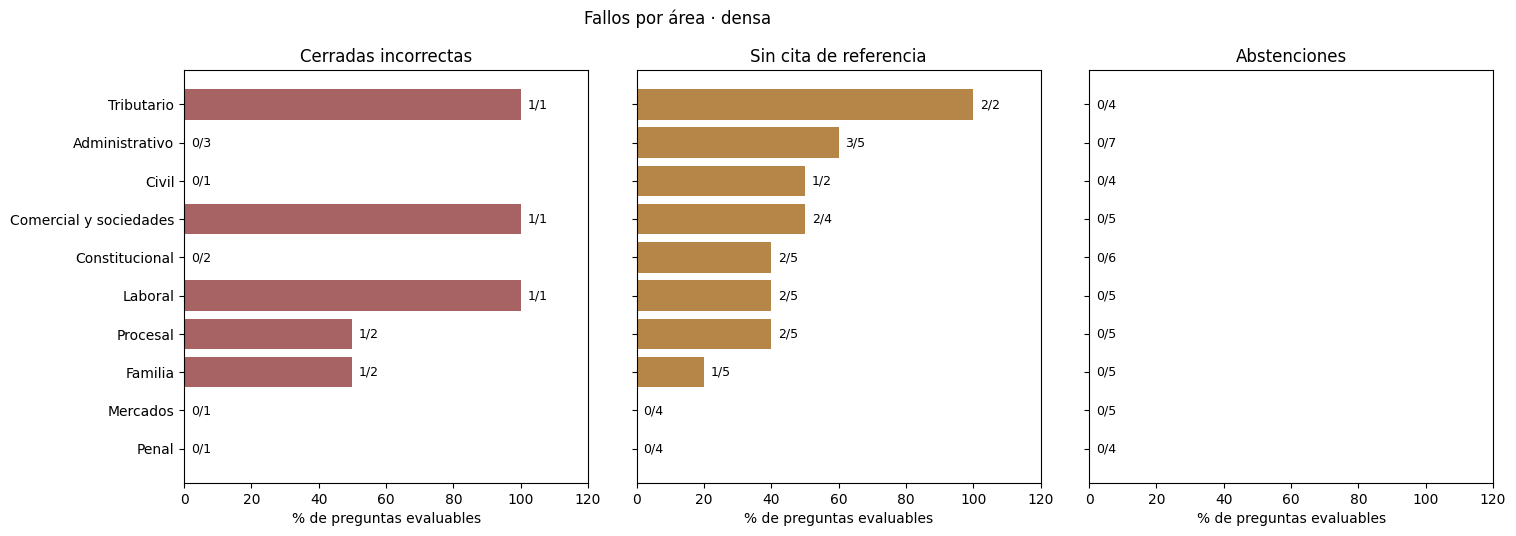

In [8]:
import matplotlib.pyplot as plt
import numpy as np

variante_area = resumen_04["total_50"].idxmax()
ruta_diagnostico = CARPETA_04 / variante_area / "diagnostico.json"
detalle_area = pd.DataFrame(json.loads(ruta_diagnostico.read_text(encoding="utf-8")))
detalle_area["cerrada"] = detalle_area["formato"].eq("multiple_choice")
detalle_area["cerrada_fallida"] = detalle_area["cerrada"] & ~detalle_area["acierto_cerrada"].fillna(False).astype(bool)
detalle_area["cita_evaluable"] = detalle_area["ref_citas"].fillna(0).gt(0)
detalle_area["cita_fallida"] = detalle_area["cita_evaluable"] & detalle_area["citas_aciertos"].fillna(0).eq(0)

areas = detalle_area.groupby("area").agg(
    preguntas=("id", "size"),
    cerradas=("cerrada", "sum"),
    cerradas_fallidas=("cerrada_fallida", "sum"),
    con_cita=("cita_evaluable", "sum"),
    sin_cita_correcta=("cita_fallida", "sum"),
    abstenciones=("abstencion", "sum"),
)
areas["tasa_citas"] = np.divide(
    areas["sin_cita_correcta"], areas["con_cita"].replace(0, np.nan)
)
areas = areas.sort_values(["tasa_citas", "abstenciones"], ascending=False)
print("Variante:", variante_area)
display(areas.drop(columns="tasa_citas"))

nombres = [a.replace("Derecho de los mercados [competencia, consumidor, datos personales y propiedad intelectual]", "Mercados")
             .replace("Derecho de ", "").replace("Derecho ", "").capitalize() for a in areas.index]
posiciones = np.arange(len(areas))
fig, ejes = plt.subplots(1, 3, figsize=(17, max(5, 0.55 * len(areas))), sharey=True)
metricas = [
    ("cerradas_fallidas", "cerradas", "Cerradas incorrectas", "#a76363"),
    ("sin_cita_correcta", "con_cita", "Sin cita de referencia", "#b68649"),
    ("abstenciones", "preguntas", "Abstenciones", "#6484a1"),
]
for eje, (col_fallos, col_total, titulo, color) in zip(ejes, metricas):
    fallos = areas[col_fallos].to_numpy(dtype=float)
    totales = areas[col_total].to_numpy(dtype=float)
    tasas = np.divide(fallos, totales, out=np.zeros_like(fallos), where=totales > 0) * 100
    eje.barh(posiciones[totales > 0], tasas[totales > 0], color=color)
    for pos, tasa, fallo, total in zip(posiciones, tasas, fallos, totales):
        etiqueta = f"{int(fallo)}/{int(total)}" if total else "sin datos"
        eje.text(min(tasa + 2, 102) if total else 2, pos, etiqueta, va="center", fontsize=9)
    eje.set_title(titulo)
    eje.set_xlim(0, 120)
    eje.set_xlabel("% de preguntas evaluables")
    eje.set_yticks(posiciones, nombres)
ejes[0].invert_yaxis()
fig.suptitle(f"Fallos por área · {variante_area}")
fig.subplots_adjust(left=0.21, right=0.98, top=0.87, bottom=0.12, wspace=0.12)
plt.show()


In [9]:
variante_revisar = "densa"
t = pareadas[variante_revisar]
display(t[t["cambio"].isin(["rota", "igual_mal"])])

,id,formato,area,abst_03,abst_04,acierto_03,acierto_04,citas_ok_03,citas_ok_04,sin_respaldo_04,cambio
5,128,multiple_choice,Derecho comercial y sociedades,True,False,False,False,0,1,0,igual_mal
26,528,multiple_choice,Derecho procesal,True,False,False,False,0,1,0,igual_mal
30,617,multiple_choice,Derecho laboral,True,False,False,False,0,0,0,igual_mal
31,647,multiple_choice,Derecho de familia,False,False,True,False,0,1,0,rota
33,671,multiple_choice,Derecho tributario,True,False,False,False,0,0,0,igual_mal
12,247,open_ended,Derecho administrativo,False,False,None,None,0,0,0,igual_mal
25,513,open_ended,"Derecho de los mercados [competencia, consumid...",True,False,None,None,0,0,0,igual_mal
35,679,open_ended,Derecho constitucional,False,False,None,None,0,0,0,igual_mal
0,24,semi_open,Derecho civil,True,False,None,None,0,0,0,igual_mal
6,140,semi_open,Derecho comercial y sociedades,True,False,None,None,0,0,0,igual_mal


## Otro decoder

La comparación con Qwen2.5-7B está disponible. Se deja desactivada hasta revisar los resultados de Salamandra.


In [10]:
correr_otro_decoder = False
if correr_otro_decoder:
    config_qwen = {**config, "decoder": "qwen2.5-7b-instruct"}
    CARPETA_QWEN = v04.ejecutar(RAIZ, CARPETA_RECUP, RESULTADOS, variantes, config=config_qwen,
                                cache_modelos=CACHE_MODELOS, nombre="qwen25_v04")
    display(pd.DataFrame({v: json.loads((CARPETA_QWEN / v / "resumen.json").read_text()) for v in variantes}).T)

## Juez oficial

La llave solo se usa para ejecutar el evaluador oficial. En Colab, guardarla en Secretos con el nombre `OPENROUTER_API_KEY` y dar acceso al notebook. En local, usar una variable de entorno o `scripts/.env`.

Se elige la variante con más puntos sin juez. La evaluación se guarda para no repetir llamadas pagadas. Si cambian las respuestas, activar `repetir_juez`. El juez entrega un puntaje total de texto libre, no resultados por área.


In [11]:
usar_juez = False
repetir_juez = False
variante_juez = resumen_04["total_50"].idxmax()
carpeta_finalista = CARPETA_04 / variante_juez
salida_juez = carpeta_finalista / "evaluacion_con_ragas.json"

if usar_juez:
    if repetir_juez or not salida_juez.is_file():
        if EN_COLAB:
            from google.colab import userdata
            llave = userdata.get("OPENROUTER_API_KEY")
        else:
            llave = os.environ.get("OPENROUTER_API_KEY")
            if not llave:
                for ruta_env in (RAIZ / "scripts/.env", RAIZ / "data/oficial/scripts/.env"):
                    if ruta_env.is_file():
                        for linea in ruta_env.read_text(encoding="utf-8").splitlines():
                            if linea.strip().startswith("OPENROUTER_API_KEY="):
                                llave = linea.split("=", 1)[1].strip().strip('"').strip("'")
                                break
                    if llave:
                        break
        if not llave:
            raise RuntimeError("Falta OPENROUTER_API_KEY en Secretos de Colab o en el entorno local")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                        str(RAIZ / "data/oficial/scripts/requirements-evaluador.txt")], check=True)
        entorno_juez = {**os.environ, "OPENROUTER_API_KEY": llave}
        comando_juez = [sys.executable, str(RAIZ / "data/oficial/scripts/evaluate.py"),
                        "--submission", str(carpeta_finalista / "submissions.jsonl"),
                        "--split", "sample", "--ragas", "--out", str(salida_juez)]
        proceso_juez = subprocess.run(comando_juez, cwd=RAIZ / "data/oficial",
                                     env=entorno_juez, capture_output=True, text=True)
        del llave, entorno_juez
        if proceso_juez.returncode:
            raise RuntimeError("Falló el evaluador oficial: " + proceso_juez.stderr[-2000:])
    reporte_juez = json.loads(salida_juez.read_text(encoding="utf-8"))
    print("Variante evaluada:", variante_juez)
    display(pd.DataFrame([{
        "cerradas_20": reporte_juez["cerradas"]["puntos"],
        "citas_20": reporte_juez["citas"]["puntos"],
        "abstencion_10": reporte_juez["abstencion"]["puntos"],
        "texto_libre_30": reporte_juez["correccion_ragas"]["puntos"],
        "total_80": reporte_juez["total_automatico"]["obtenidos"],
    }]))


## Resultados y decisiones

Pendiente de esta ejecución. Revisar el puntaje completo, las preguntas que cambiaron y la gráfica por área antes de elegir la variante final.
